# 서울 공공 자전거 데이터 

In [2]:
import os 
import pandas as pd
import numpy as np
from plt_rcs import *
import hds

In [3]:
plt.rc(group='figure', figsize=(12, 4))

In [4]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [5]:
os.chdir('../../data')

In [6]:
[i for i in os.listdir() if 'Bike' in i][0]

'Seoul_Bike_Daily_2021_2025.csv'

In [7]:
df = pd.read_csv('Seoul_Bike_Daily_2021_2025.csv')

In [8]:
df.head()

,RENT_DT,USE_CNT
0,2021-01-01,21873
1,2021-01-02,23185
2,2021-01-03,21410
3,2021-01-04,32436
4,2021-01-05,28598


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1820 entries, 0 to 1819
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   RENT_DT  1820 non-null   object
 1   USE_CNT  1820 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 28.6+ KB


In [10]:
df.describe().round(3)

,USE_CNT
count,1820.000
mean,108617.381
std,49101.571
min,482.000
25%,68508.500
50%,111348.000
75%,148793.250
max,210999.000


## 데이터 전처리

In [11]:
# 날짜시간형으로 변환
df['RENT_DT'] = pd.to_datetime(arg=df['RENT_DT'], errors='coerce')

In [12]:
# 날짜시간형 컬럼은 인덱스로 설정
df = df.set_index('RENT_DT').sort_index()

In [13]:
df.head()

,USE_CNT
RENT_DT,
2021-01-01,21873
2021-01-02,23185
2021-01-03,21410
2021-01-04,32436
2021-01-05,28598


## 시계열 인덱스 확인

In [14]:
# 중복건 확인
df.index.duplicated(False).sum()
# 0

0

In [15]:
# 인덱스의 최솟값과 최댓값으로 기대 인덱스 생성
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')

In [16]:
# 누락 인덱스 개수 확인
full_idx.difference(df.index).size
# 6

6

In [ ]:
# 누락 인덱스를 행으로 추가
df = df.reindex(full_idx).rename_axis(index='RENT_DT')

In [18]:
df.head()

,USE_CNT
RENT_DT,
2021-01-01,21873.0
2021-01-02,23185.0
2021-01-03,21410.0
2021-01-04,32436.0
2021-01-05,28598.0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2021-01-01 to 2025-12-31
Freq: D
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USE_CNT  1820 non-null   float64
dtypes: float64(1)
memory usage: 93.1 KB


## 결측값 처리

In [ ]:
df.loc[df['USE_CNT'].isna()] # 결측인 행 확인
#               USE_CNT
# RENT_DT	
# 2021-06-25	NaN
# 2021-06-26	NaN
# 2021-06-27	NaN
# 2021-06-28	NaN
# 2021-06-29	NaN
# 2021-06-30	NaN

,USE_CNT
RENT_DT,
2021-06-25,NaN
2021-06-26,NaN
2021-06-27,NaN
2021-06-28,NaN
2021-06-29,NaN
2021-06-30,NaN


- 연속 6일 동안 결측 발생 -> 단순 일시적 누락이 아닌 구조적 결측 가능성 높음

In [21]:
df = df.dropna() # 결측인 행 모두 삭제

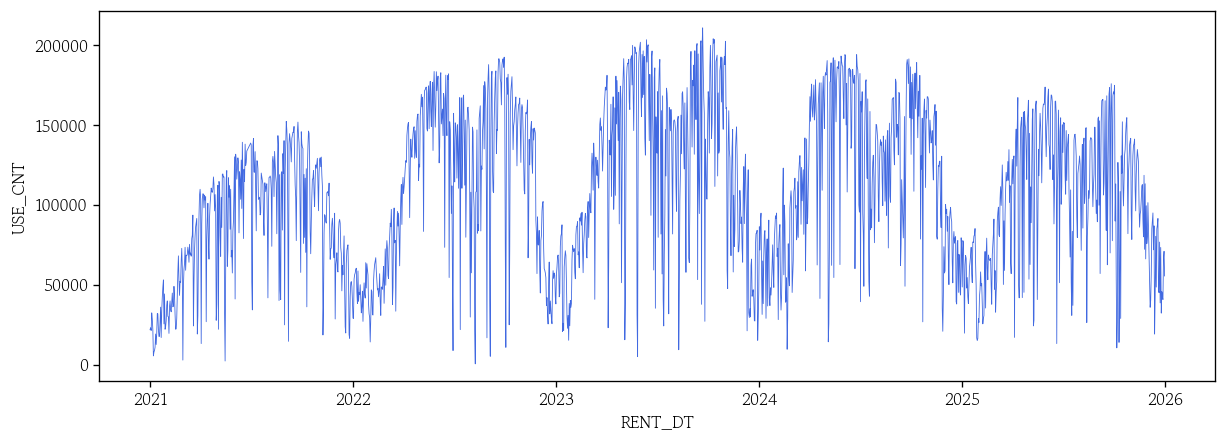

In [22]:
sns.lineplot(data=df, x=df.index, y='USE_CNT', color='royalblue', linewidth=0.5)
plt.show()

## 시계열 분해

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose

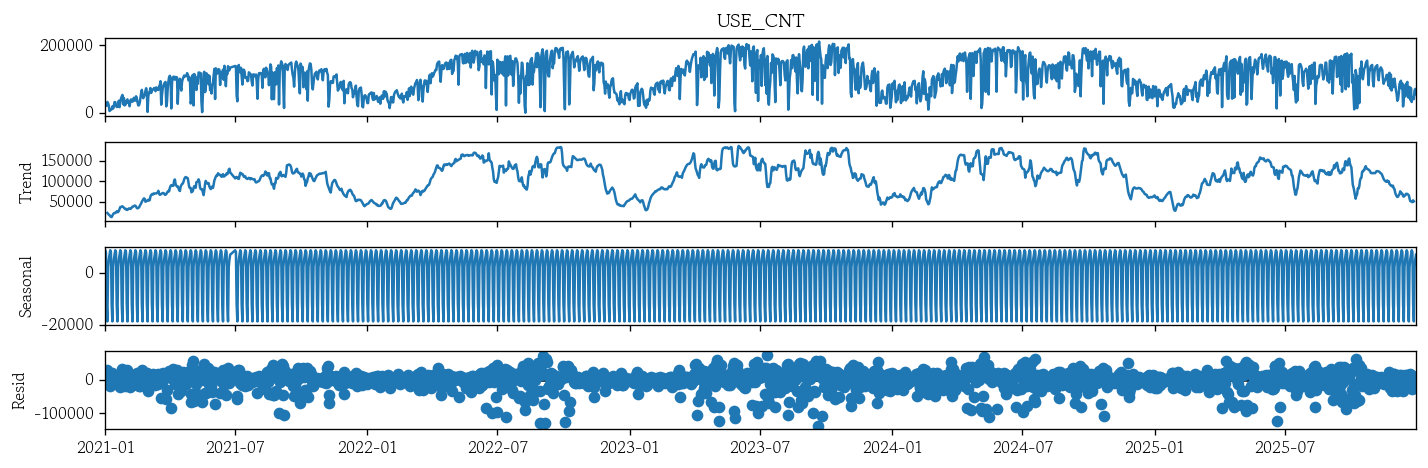

In [24]:
result = seasonal_decompose(x=df['USE_CNT'], model='additive', period=7)
result.plot();

## 실습 데이터셋 분할

In [25]:
std_date = '2025-01-01' # 훈련셋과 시험셋으로 분할하는 기준일자 설정

In [26]:
train = df.loc[:std_date].iloc[:-1]
test = df.loc[std_date:]

## 정수 인덱스 생성

In [27]:
n_train = len(train) # 훈련셋 크기 생성

In [28]:
train_idx = np.arange(n_train).reshape(-1, 1) # 인덱스를 수치형으로 변환

In [29]:
n_test = len(test) # 시험셋 크기 생성

In [ ]:
test_idx = np.arange(n_train, n_train + n_test).reshape(-1, 1) # 인덱스를 수치형으로 변환

## 기준선 모형

In [31]:
nm_pred = pd.concat(objs=[train, test])['USE_CNT'].shift(1).loc[test.index] # 단순 기법 예측

In [32]:
ma_pred = pd.concat(objs=[train, test])['USE_CNT'].rolling(window=7).mean().shift(1).loc[test.index] # 이동 평균 예측

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression() # 단순 선형 회귀 모형 생성

In [35]:
model.fit(X=train_idx, y=train['USE_CNT']) # 훈련셋으로 모형 학습

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
lr_pred = pd.Series(data=model.predict(X=test_idx), index=test.index) # 단순 회귀 기반 예측

In [37]:
y_1, y_t = train['USE_CNT'].iloc[[0, -1]] # 훈련셋의 첫 번째 값과 마지막 값을 생성

In [38]:
drift = (y_t - y_1) / (n_train - 1) # 평균 일별 변화량 계산

In [39]:
h = np.arange(1, n_test + 1) # ㅣ험셋의 일수 차이 계산

In [40]:
dm_pred = pd.Series(data=y_t + h * drift, index=test.index) # 시험셋으로 표퓨 기법 예측값 생성

## 시각적 비교

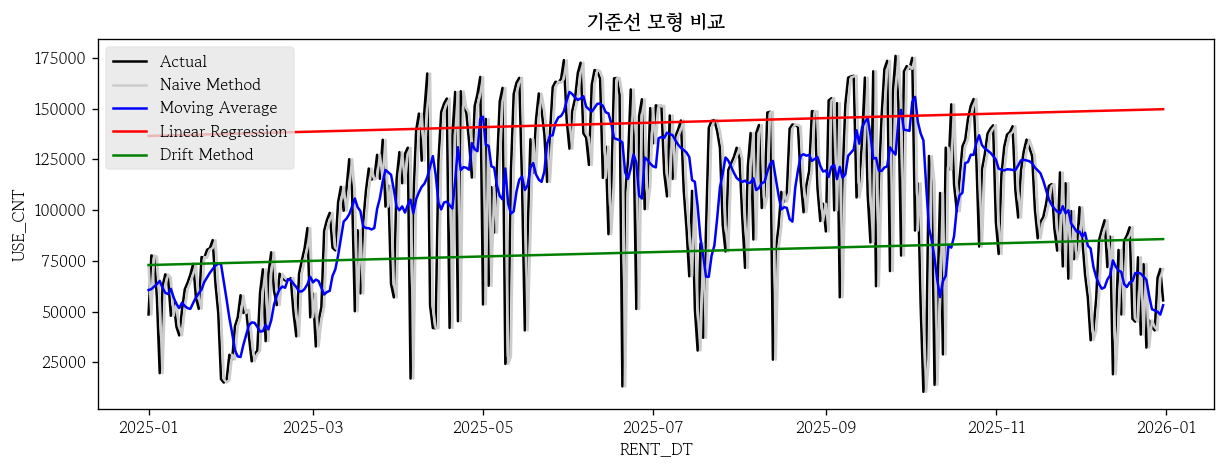

In [41]:
sns.lineplot(x=test.index, y=test['USE_CNT'], label='Actual', color='0')
sns.lineplot(x=test.index, y=nm_pred, label='Naive Method', color='0.8')
sns.lineplot(x=test.index, y=ma_pred, label='Moving Average', color='blue')
sns.lineplot(x=test.index, y=lr_pred, label='Linear Regression', color='red')
sns.lineplot(x=test.index, y=dm_pred, label='Drift Method', color='green')
plt.title(label='기준선 모형 비교', fontweight='bold')
plt.legend(loc='upper left')
plt.show()

## 모형 예측 성능 평가

In [43]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=nm_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)

,metric,score
0,RMSE,37922.049022
1,MAPE,0.415730


In [44]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=ma_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)

,metric,score
0,RMSE,33438.358141
1,MAPE,0.441302


In [45]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=lr_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)

,metric,score
0,RMSE,58514.374134
1,MAPE,0.927447


In [46]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=dm_pred).loc[[2, 6], ['metric', 'score']].reset_index(drop=True)

,metric,score
0,RMSE,47717.372764
1,MAPE,0.504954


## 인덱스에 freq 설정

In [47]:
train = train.asfreq('D')
test = test.asfreq('D')

## 외부 파일로 저장

In [48]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/data'

In [49]:
objs = {
    'df': df,
    'train': train,
    'test': test
}

In [50]:
pd.to_pickle(obj=objs, filepath_or_buffer='Seoul_Bike_Prep.pkl')